# **Практическая работа №11. Обработка больших пространственных данных в среде Google Earth Engine**

Перед выполнением заданий необходимо ознакомиться (вспомнить) и запустить последовательно следующий материал:

1. [**Geemap. Часть 1: Подготовка среды и базовые картографические инструменты**](https://colab.research.google.com/drive/1ZQsl0L6yt4YEZ40Pb97KnTFjYK5zslcE?usp=sharing)
2. [**Geemap. Часть 2: Геопространственный анализ и экспорт результатов**](https://colab.research.google.com/drive/19wOWQc80TiZSNy9foAc8qP5EqpbaBD62?usp=sharing)
3. [**Geemap. Часть 3: Расширенные средства визуализации и анализа данных**](https://colab.research.google.com/drive/1yN5f8gJQs6ZoAyZNfjNclRv0EB83qPGz?usp=sharing)

## **Устанавливаем необходимые зависимости и авторизуемся в Google Earth Engine (GEE)**

P.S.: Необходимо заранее создать в GEE проект и сделать его некоммерческим в настройках, см. первую часть теории.

In [1]:
%%capture
!pip install -U "geemap[workshop]"

In [2]:
import ee
import geemap

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
ee.Authenticate()
ee.Initialize(project='feed-project-469822')

## **Задание 1. Визуализация данных цифровой модели рельефа (ЦМР)**



Найдите набор данных ЦМР в [Каталоге данных Earth Engine](https://developers.google.com/earth-engine/datasets) и выполните обрезку растра по границам выбранной территории (например, вашей страны, региона или города - полигоны можно загрузить в OSM). Отобразите результат с использованием подходящей **цветовой палитры**.

In [73]:
rostov_center = ee.Geometry.Point(
    coords=[39.7015, 47.2357],
    proj='EPSG:4326',
    geodesic=False
)

In [74]:
rostov_square = rostov_center.buffer(50_000).bounds()

In [75]:
dem = ee.Image("NASA/NASADEM_HGT/001")

In [76]:
dem_elevation = dem.select("elevation")
dem_rostov = dem_elevation.clip(rostov_square)

In [78]:
dem_vis = {
    "min": 0,
    "max": 120,
    "palette": [
        "#313695",
        "#74add1",
        "#abd9e9",
        "#e0f3f8",
        "#ffffbf",
        "#fee090",
        "#fdae61",
        "#f46d43",
        "#d73027"
    ]
}

map = geemap.Map(center=[47.222109, 39.718813], zoom=10)

map.addLayer(dem_rostov, dem_vis, "NASADEM Rostov-on-Don")

map.addLayer(
    ee.FeatureCollection([ee.Feature(rostov_square)]).style(
        color="000000",
        fillColor="00000000",
        width=2
    ),
    {},
    "Rostov square boundary"
)

map


Map(center=[47.222109, 39.718813], controls=(WidgetControl(options=['position', 'transparent_bg'], position='t…

---

## **Задание 2. Создание безоблачного композита на основе данных Sentinel-2 или Landsat**



Используйте данные [Sentinel-2](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED) или [Landsat-9](https://developers.google.com/earth-engine/datasets/catalog/landsat-9) для создания **безоблачного композитного изображения** за определённый год для выбранного вами региона. Отобразите полученное изображение на карте с применением соответствующей **комбинации спектральных каналов**.


In [106]:
def mask_s2_clouds_sr(image):
    """
    Mask clouds using SCL band and scale reflectance.

    :param image: Sentinel-2 image

    :return: Masked and scaled image
    """
    scl = image.select("SCL")
    mask = scl.gte(4).And(scl.lte(11))
    return image.updateMask(mask).divide(10000)

In [107]:
s2_col = (
    ee.ImageCollection("COPERNICUS/S2_SR")
    .filterBounds(rostov_square)
    .filterDate("2024-07-01", "2024-10-01")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 5))
    .map(mask_s2_clouds_sr)
)

In [108]:
s2_mosaic = s2_col.median().clip(rostov_square)

In [109]:
vis_params = {
    "bands": ["B4", "B3", "B2"],
    "min": 0,
    "max": 0.3,
    "gamma": 1.3
}

In [110]:
mlst = geemap.Map()
mlst.centerObject(rostov_square, 9)

mlst.addLayer(
    s2_mosaic,
    vis_params,
    "Sentinel-2 RGB Ростов-на-Дону (2024)"
)

mlst.addLayer(
    ee.FeatureCollection([ee.Feature(rostov_square)]).style(
        color="000000",
        fillColor="00000000",
        width=2
    ),
    {},
    "Граница исследуемой территории"
)

mlst


Map(center=[47.23514094856318, 39.70317755414856], controls=(WidgetControl(options=['position', 'transparent_b…

## **Задание 3. Визуализация аэрофотоснимков NAIP**


Используйте данные [NAIP](https://developers.google.com/earth-engine/datasets/catalog/USDA_NAIP_DOQQ) (Национальная программа аэрофотосъёмки сельскохозяйственных угодий США) для создания безоблачного изображения выбранного вами округа США. В качестве примера на карте ниже представлен безоблачный композит NAIP в **натуральных цветах** (true-color) для округа Нокс, штат Теннесси. Обратите внимание, что в разных штатах могут существовать округа с одинаковыми названиями — убедитесь, что выбран корректный округ для указанного штата.

![](https://i.imgur.com/iZSGqGS.png)

In [111]:
# Загружаем границы округов США
us_counties = ee.FeatureCollection("TIGER/2018/Counties")

# Выбираем Knox County, Tennessee
knox_county = us_counties.filter(
    ee.Filter.And(
        ee.Filter.eq("NAME", "Knox"),
        ee.Filter.eq("STATEFP", "47")  # код штата Tennessee
    )
)

knox_county

In [112]:
m = geemap.Map()
m.centerObject(knox_county, 9)

m.addLayer(
    knox_county.style(
        color="black",
        fillColor="00000000",
        width=2
    ),
    {},
    "Округ Нокс, штат Теннесси"
)

m

Map(center=[35.993196068178555, -83.93723059189078], controls=(WidgetControl(options=['position', 'transparent…

In [113]:
naip = ee.ImageCollection("USDA/NAIP/DOQQ")

In [114]:
naip_2021 = (
    naip
    .filterBounds(knox_county)
    .filterDate("2021-01-01", "2021-12-31")
)

In [115]:
naip_composite = naip_2021.median().clip(knox_county)

In [116]:
naip_vis = {
    "bands": ["R", "G", "B"],
    "min": 0,
    "max": 255
}


In [117]:
m = geemap.Map()
m.centerObject(knox_county, 10)

m.addLayer(
    naip_composite,
    naip_vis,
    "NAIP — натуральные цвета (округ Нокс, 2021)"
)

m.addLayer(
    knox_county.style(
        color="black",
        fillColor="00000000",
        width=2
    ),
    {},
    "Граница округа"
)

m


Map(center=[35.993196068178555, -83.93723059189078], controls=(WidgetControl(options=['position', 'transparent…

## **Задание 4. Визуализация границ водосборных бассейнов**



Выполните визуализацию данных [USGS Watershed Boundary Dataset](https://developers.google.com/earth-engine/datasets/catalog/USGS_WBD_2017_HUC04) (Набор данных границ водосборных бассейнов Геологической службы США), отображая **только контурные линии** без заливки полигонов.

![](https://i.imgur.com/PLlNFq3.png)

In [123]:
wbd = ee.FeatureCollection("USGS/WBD/2017/HUC12")  # HUC12 — мелкие водосборные бассейны

wbd_knox = wbd.filterBounds(knox_county)

In [124]:
wbd_style = {
    "color": "0000FF",      # синий контур
    "fillColor": "00000000",  # полностью прозрачная заливка
    "width": 2
}

In [125]:
m = geemap.Map()
m.centerObject(knox_county, 8)

# Границы водосборных бассейнов
m.addLayer(
    wbd_knox.style(**wbd_style),
    {},
    "Границы водосборных бассейнов (USGS WBD)"
)

# Граница округа (для ориентира)
m.addLayer(
    knox_county.style(
        color="black",
        fillColor="00000000",
        width=2
    ),
    {},
    "Граница округа"
)

m


Map(center=[35.993196068178555, -83.93723059189078], controls=(WidgetControl(options=['position', 'transparent…

## **Задание 5. Визуализация динамики земельного покрова**


5.1. Ознакомьтесь с примерами по ссылке: [Расширенные средства визуализации данных Earth Engine](https://colab.research.google.com/drive/1yN5f8gJQs6ZoAyZNfjNclRv0EB83qPGz?usp=sharing#scrollTo=e2a888fb)

5.2. Используйте данные [USGS National Land Cover Database](https://developers.google.com/earth-engine/datasets/catalog/USGS_NLCD_RELEASES_2019_REL_NLCD) (Национальная база данных земельного покрова) и [US Census States](https://developers.google.com/earth-engine/datasets/catalog/TIGER_2018_States) (границы штатов США) для создания **карты с разделённым экраном** (split-panel map), позволяющей визуализировать изменения земельного покрова за период 2001–2019 гг. для выбранного штата США. Не забудьте добавить на карту **легенду классификации NLCD**.

![](https://i.imgur.com/Au7Q5Ln.png)

In [133]:
mclass = geemap.Map(center=[35.8, -86.4], zoom=6)

states = ee.FeatureCollection("TIGER/2018/States")
state = states.filter(ee.Filter.eq("NAME", "Tennessee"))

In [135]:
nlcd_2001 = (
    ee.Image("USGS/NLCD_RELEASES/2019_REL/NLCD/2001")
    .select("landcover")
    .clip(state.geometry())
)

nlcd_2019 = (
    ee.Image("USGS/NLCD_RELEASES/2019_REL/NLCD/2019")
    .select("landcover")
    .clip(state.geometry())
)

In [136]:
left_layer = geemap.ee_tile_layer(
    nlcd_2001,
    {},
    "Земельный покров NLCD — 2001"
)

right_layer = geemap.ee_tile_layer(
    nlcd_2019,
    {},
    "Земельный покров NLCD — 2019"
)

In [137]:
mclass.split_map(left_layer, right_layer)
mclass.add_legend(builtin_legend="NLCD")

In [139]:
mclass.addLayer(
    state.style(
        color="black",
        fillColor="00000000",
        width=2
    ),
    {},
    "Граница штата Теннесси"
)


In [140]:
mclass

Map(center=[35.8, -86.4], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

## **Задание 6. Создание таймлапс-анимации на основе данных Landsat**


6.1. Ознакомьтесь с примером по ссылке: [Создание анимаций временных рядов](https://colab.research.google.com/drive/1yN5f8gJQs6ZoAyZNfjNclRv0EB83qPGz?usp=sharing#scrollTo=a7112c2c)


6.2. Сгенерируйте **покадровую анимацию** (timelapse) с использованием данных Landsat для демонстрации многолетней динамики изменений выбранной территории.

![Spain](https://github.com/user-attachments/assets/f12839c0-1c30-404d-b0ab-0fa12ce12d24)

---



In [142]:
states = ee.FeatureCollection("TIGER/2018/States")
state = states.filter(ee.Filter.eq("NAME", "Tennessee"))

timelapse = geemap.landsat_timelapse(
    state.geometry(),
    out_gif="tennessee_landsat_2000_2020.gif",
    start_year=2000,
    end_year=2020,
    bands=["Red", "Green", "Blue"],
    frames_per_second=2,
    title="Tennessee: Landsat 2000–2020",
    font_color="white"
)

geemap.show_image(timelapse)



Generating URL...
Please wait ...
The GIF image has been saved to: /content/tennessee_landsat_2000_2020.gif


Output()

## **Задание 7. Классификация земного покрова с применением методов машинного обучения и отбором признаков**

7.1. Ознакомьтесь с материалом по ссылке: [Экспорт растровых данных и применение методов машинного обучения в среде Google Earth Engine](https://colab.research.google.com/drive/1BU-Q4D0XEIy2KiEtzw-3dKISE0lwGLV2?usp=sharing)

7.2. Создайте интерактивную карту и определите **область интереса** (ROI) для классификации. Область должна отличаться от примера в методическом материале.

In [143]:
map_roi = geemap.Map(center=[35.95, -83.95], zoom=11)

map_roi.add_draw_control()

map_roi

Map(center=[35.95, -83.95], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [185]:
roi = map_roi.user_roi

map_check = geemap.Map()
map_check.centerObject(roi, 12)

map_check.addLayer(
    roi,
    {"color": "red"},
    "Область интереса (ROI)"
)

map_check

Map(center=[35.98766920591697, -83.89709500000049], controls=(WidgetControl(options=['position', 'transparent_…



7.3. Загрузите коллекцию снимков **Sentinel-2** за вегетационный период (май–сентябрь) выбранного года. Примените фильтрацию по облачности и создайте функцию **маскирования облаков** на основе канала QA60.

In [186]:
def mask_s2_clouds(image):
    """
    Mask clouds and cirrus using QA60 band.

    :param image: Sentinel-2 image

    :return: Cloud-masked and scaled image
    """
    # Канал качества
    qa = image.select("QA60")

    # Биты QA60:
    # 10 — облака
    # 11 — перистые облака
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    # Маска: оставляем только чистые пиксели
    mask = (
        qa.bitwiseAnd(cloud_bit_mask).eq(0)
        .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    )

    # Применяем маску и нормализуем значения (0–1)
    return (
        image
        .updateMask(mask)
        .divide(10000)
        .copyProperties(image, ["system:time_start"])
    )


In [187]:
year = 2023

s2_collection = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(roi)
    .filterDate(f"{year}-05-01", f"{year}-09-30")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .map(mask_s2_clouds)
)

print(
    "Количество снимков Sentinel-2:",
    s2_collection.size().getInfo()
)

Количество снимков Sentinel-2: 61


In [188]:
sample_image = s2_collection.first()

vis_params = {
    "bands": ["B4", "B3", "B2"],
    "min": 0.0,
    "max": 0.3,
    "gamma": 1.3
}

map_check = geemap.Map()
map_check.centerObject(roi, 12)
map_check.addLayer(sample_image, vis_params, "Sentinel-2 (QA60, без облаков)")
map_check.addLayer(roi, {"color": "red"}, "ROI")

map_check


Map(center=[35.98766920591697, -83.89709500000049], controls=(WidgetControl(options=['position', 'transparent_…

7.4. Создайте **безоблачный медианный композит** из отфильтрованной коллекции и отобразите его на карте в естественных цветах (RGB: B4, B3, B2).

In [189]:
s2_composite = (
    s2_collection
    .median()
    .clip(roi)
)

rgb_vis = {
    "bands": ["B4", "B3", "B2"],
    "min": 0.0,
    "max": 0.3,
    "gamma": 1.3
}

map_comp = geemap.Map()
map_comp.centerObject(roi, 12)

map_comp.addLayer(
    s2_composite,
    rgb_vis,
    "Sentinel-2 медианный композит (RGB)"
)

map_comp


Map(center=[35.98766920591697, -83.89709500000049], controls=(WidgetControl(options=['position', 'transparent_…

7.5. Рассчитайте **спектральные индексы** и добавьте их в качестве дополнительных каналов изображения:
- **NDVI** — нормализованный вегетационный индекс
- **NDWI** — нормализованный водный индекс
- **NDBI** — нормализованный индекс застройки
- **EVI** — улучшенный вегетационный индекс

In [190]:
ndvi = s2_composite.normalizedDifference(["B8", "B4"]).rename("NDVI")
ndwi = s2_composite.normalizedDifference(["B3", "B8"]).rename("NDWI")
ndbi = s2_composite.normalizedDifference(["B11", "B8"]).rename("NDBI")

evi = s2_composite.expression(
    "2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))",
    {
        "NIR": s2_composite.select("B8"),
        "RED": s2_composite.select("B4"),
        "BLUE": s2_composite.select("B2"),
    }
).rename("EVI")

In [191]:
s2_features = (
    s2_composite
    .addBands([ndvi, ndwi, ndbi, evi])
)

s2_features.bandNames()

In [192]:
# NDVI — растительность
ndvi_vis = {
    "min": -1,
    "max": 1,
    "palette": ["blue", "white", "green"]
}

# NDWI — вода
ndwi_vis = {
    "min": -1,
    "max": 1,
    "palette": ["brown", "white", "blue"]
}

# NDBI — застройка
ndbi_vis = {
    "min": -1,
    "max": 1,
    "palette": ["green", "white", "red"]
}

# EVI — растительность (усиленная)
evi_vis = {
    "min": -1,
    "max": 1,
    "palette": ["purple", "white", "darkgreen"]
}

map_indices = geemap.Map()
map_indices.centerObject(roi, 12)

map_indices.addLayer(ndvi, ndvi_vis, "NDVI — растительность")
map_indices.addLayer(ndwi, ndwi_vis, "NDWI — вода")
map_indices.addLayer(ndbi, ndbi_vis, "NDBI — застройка")
map_indices.addLayer(evi, evi_vis, "EVI — растительность (улучш.)")

map_indices

Map(center=[35.98766920591697, -83.89709500000049], controls=(WidgetControl(options=['position', 'transparent_…

7.6. Загрузите эталонные данные о земном покрове из набора [ESA WorldCover](https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v200) и сформируйте **первичную обучающую выборку** со всеми спектральными каналами и индексами.

In [193]:
worldcover = (
    ee.Image("ESA/WorldCover/v200/2021")
    .select("Map")
    .clip(roi)
)

In [194]:
worldcover_vis = {
    "min": 10,
    "max": 100,
    "palette": [
        '#006400',  # 10 - Деревья - темно-зеленый
        '#7cfc00',  # 20 - Кустарники - светло-зеленый
        '#9acd32',  # 30 - Травянистая растительность - желто-зеленый
        '#f0e68c',  # 40 - Пахотные земли - хаки
        '#ff0000',  # 50 - Застроенные территории - красный
        '#d2691e',  # 60 - Голая почва - коричневый
        '#ffffff',  # 70 - Снег и лед - белый
        '#1e90ff',  # 80 - Вода - синий
        '#00bfff',  # 90 - Водно-болотные угодья - голубой
        '#008b8b',  # 95 - Мангровые заросли - темно-бирюзовый
        '#98fb98'   # 100 - Мхи и лишайники - бледно-зеленый
    ],
}

map_wc = geemap.Map()
map_wc.centerObject(roi, 12)
map_wc.addLayer(worldcover, worldcover_vis, "ESA WorldCover")
map_wc


Map(center=[35.98766920591701, -83.89709500000049], controls=(WidgetControl(options=['position', 'transparent_…

In [195]:
training_image = s2_features.addBands(worldcover.rename("landcover"))

training_samples = training_image.sample(
    region=roi,
    scale=10,
    numPixels=5000,
    seed=42,
    geometries=True
)

In [196]:
training_samples.limit(5)

In [197]:
training_samples.size().getInfo()

4135

7.7. **Анализ мультиколлинеарности признаков.** Извлеките значения признаков из обучающей выборки в формат `pandas.DataFrame` и постройте **матрицу корреляции Пирсона** для всех спектральных каналов и индексов.

Визуализируйте её в виде тепловой карты (`seaborn.heatmap`).


In [201]:
bands = [
    "B2", "B3", "B4", "B5", "B6", "B7",
    "B8", "B8A", "B11", "B12",
    "NDVI", "NDWI", "NDBI", "EVI"
]

In [202]:
properties = training_samples.first().propertyNames().getInfo()
print("Свойства:", properties)

Свойства: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'NDWI', 'NDBI', 'EVI', 'landcover', 'system:index']


In [203]:
def ee_fc_to_df(fc, props):
    """
    Convert ee.FeatureCollection to pandas.DataFrame.

    :param fc: Earth Engine FeatureCollection
    :param props: List of properties to extract

    :return: pandas DataFrame
    """
    values = (
        fc
        .reduceColumns(
            ee.Reducer.toList(len(props)),
            props
        )
        .get('list')
        .getInfo()
    )

    df = pd.DataFrame(values, columns=props)
    return df

In [204]:
df = ee_fc_to_df(training_samples, properties)
df.head()

,B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,...,QA60,MSK_CLASSI_OPAQUE,MSK_CLASSI_CIRRUS,MSK_CLASSI_SNOW_ICE,NDVI,NDWI,NDBI,EVI,landcover,system:index
0,0.04315,0.0374,0.0672,0.0312,0.0995,0.3108,0.35125,0.37215,0.38545,0.3932,...,0,0,0,0,0.845296,-0.694094,-0.350204,0.666517,10,0
1,0.04100,0.0496,0.0812,0.0656,0.1360,0.2957,0.34520,0.36430,0.37260,0.3700,...,0,0,0,0,0.694813,-0.635466,-0.116628,0.538820,30,1
2,0.04970,0.0564,0.0686,0.0664,0.1034,0.1871,0.22350,0.23800,0.24510,0.2704,...,0,0,0,0,0.563732,-0.552511,-0.147541,0.353552,50,2
3,0.05790,0.0816,0.0938,0.0881,0.1293,0.2502,0.29040,0.25300,0.31270,0.3057,...,0,0,0,0,0.483436,-0.459054,-0.061242,0.352471,10,3
4,0.04660,0.0548,0.0752,0.1026,0.1514,0.2269,0.25270,0.27660,0.29220,0.3016,...,0,0,0,0,0.458861,-0.572484,-0.003628,0.293681,40,4


In [206]:
features_df = df[bands]

corr_matrix = features_df.corr(method="pearson")

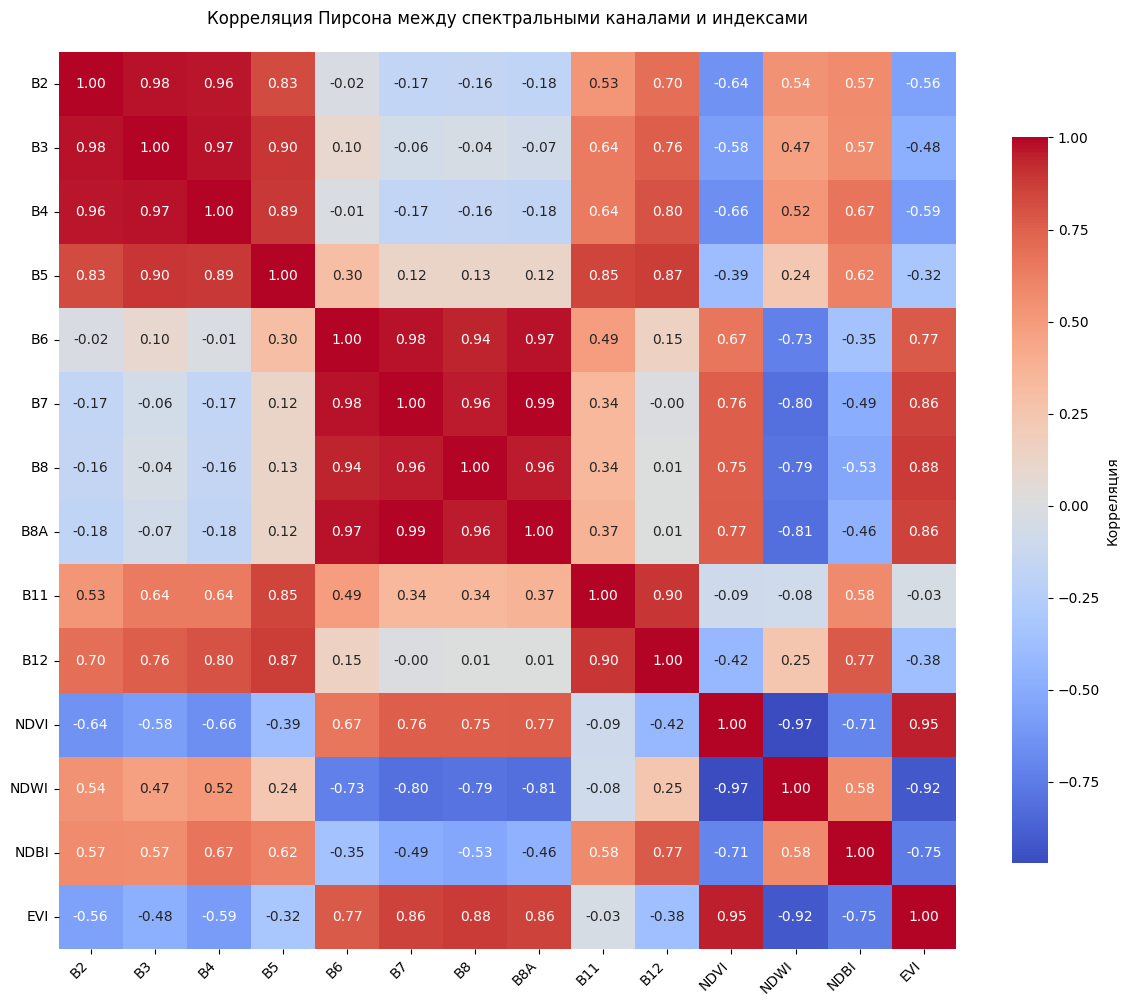

In [207]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Корреляция"}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title(
    "Корреляция Пирсона между спектральными каналами и индексами",
    pad=20
)
plt.tight_layout()
plt.show()

7.8. **Отбор признаков на основе корреляционного анализа.** Проанализируйте матрицу корреляции и выявите пары признаков с коэффициентом корреляции |r| > 0.85. Для каждой такой пары исключите один из признаков, руководствуясь следующими критериями:
- сохраняйте признаки с большей физической интерпретируемостью (например, NDVI предпочтительнее отдельного канала B8);
- при прочих равных сохраняйте признак с меньшим средним значением корреляции с остальными.

Сформируйте итоговый список признаков для обучения и обоснуйте исключение каждого удалённого признака в текстовой ячейке.





---

**Обоснование выбора признаков:**

Анализ матрицы корреляции Пирсона показал наличие выраженной мультиколлинеарности между рядом спектральных каналов Sentinel-2 и рассчитанных спектральных индексов. В первую очередь это проявляется в высокой корреляции между каналами видимого диапазона B2, B3 и B4, где значения коэффициента корреляции превышают 0.95. Поскольку данные каналы отражают близкие по физическому смыслу характеристики поверхности и несут во многом дублирующую информацию, было принято решение оставить только канал B4 как наиболее информативный и широко используемый в задачах анализа земного покрова, а каналы B2 и B3 исключить.

Сильная мультиколлинеарность также наблюдается в группе каналов red-edge и ближнего инфракрасного диапазона B6, B7, B8 и B8A, где коэффициенты корреляции между отдельными парами достигают значений 0.95–0.99. Эти каналы тесно связаны с отражательными свойствами растительности и практически повторяют друг друга. Для сокращения избыточности и повышения интерпретируемости признакового пространства вместо отдельных спектральных каналов данной группы был оставлен вегетационный индекс NDVI, который агрегирует информацию из красного и ближнего инфракрасного диапазонов и имеет чёткую физическую интерпретацию, напрямую связанную с состоянием растительного покрова.

Высокая корреляция была выявлена и между каналами коротковолнового инфракрасного диапазона B11 и B12, коэффициент корреляции между которыми превышает 0.9. В данном случае сохранён канал B11, поскольку он чаще используется в задачах классификации земного покрова и расчёта индексов застройки, в то время как канал B12 при наличии B11 не вносит существенного дополнительного вклада.

Кроме того, обнаружена сильная корреляция между вегетационными индексами NDVI и EVI, значения которой близки к 0.95. Учитывая близость физического смысла этих индексов и их высокую взаимную зависимость, для дальнейшего анализа был выбран индекс NDVI как более простой и общепринятый показатель, а индекс EVI исключён как избыточный.

При этом, несмотря на высокую по модулю отрицательную корреляцию между NDVI и NDWI, оба индекса были сохранены в итоговом наборе признаков, так как они описывают принципиально разные свойства поверхности: NDVI характеризует растительность, а NDWI — водные объекты. Сохранение обоих индексов позволяет модели корректно различать данные типы земного покрова.

---

In [211]:
final_features = [
    "B4",    # Red
    "B11",   # SWIR
    "NDVI",  # Vegetation
    "NDWI",  # Water
    "NDBI"   # Built-up
]

7.9. Разделите данные на **обучающую (70%)** и **валидационную (30%)** выборки.


In [209]:
samples_with_random = training_samples.randomColumn(
    columnName="random",
    seed=42
)

In [210]:
training_set = samples_with_random.filter(
    ee.Filter.lt("random", 0.7)
)

# Валидационная выборка (30%)
validation_set = samples_with_random.filter(
    ee.Filter.gte("random", 0.7)
)

7.10. Обучите не менее **трёх классификаторов** (например, Random Forest, Gradient Boosting и SVM) на **сокращённом наборе признаков**. Для каждой модели вычислите **матрицу ошибок**, **общую точность** (Overall Accuracy) и **коэффициент Каппа**.

In [214]:
features = final_features
label = "landcover"

rf_classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=100,
    seed=42
).train(
    features=training_set,
    classProperty=label,
    inputProperties=features
)

rf_validated = validation_set.classify(rf_classifier)

rf_confusion_matrix = rf_validated.errorMatrix(label, "classification")

print("Random Forest — матрица ошибок:")
print(rf_confusion_matrix.getInfo())

print("Overall Accuracy:", rf_confusion_matrix.accuracy().getInfo())
print("Kappa:", rf_confusion_matrix.kappa().getInfo())

Random Forest — матрица ошибок:
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [215]:
gb_classifier = ee.Classifier.smileGradientTreeBoost(
    numberOfTrees=100,
    shrinkage=0.1,
    seed=42
).train(
    features=training_set,
    classProperty=label,
    inputProperties=features
)

gb_validated = validation_set.classify(gb_classifier)

gb_confusion_matrix = gb_validated.errorMatrix(label, "classification")

print("Gradient Boosting — матрица ошибок:")
print(gb_confusion_matrix.getInfo())

print("Overall Accuracy:", gb_confusion_matrix.accuracy().getInfo())
print("Kappa:", gb_confusion_matrix.kappa().getInfo())

Gradient Boosting — матрица ошибок:
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [216]:
svm_classifier = ee.Classifier.libsvm(
    kernelType="RBF",
    gamma=0.5,
    cost=10
).train(
    features=training_set,
    classProperty=label,
    inputProperties=features
)

svm_validated = validation_set.classify(svm_classifier)

svm_confusion_matrix = svm_validated.errorMatrix(label, "classification")

print("SVM — матрица ошибок:")
print(svm_confusion_matrix.getInfo())

print("Overall Accuracy:", svm_confusion_matrix.accuracy().getInfo())
print("Kappa:", svm_confusion_matrix.kappa().getInfo())

SVM — матрица ошибок:
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

7.11. Для сравнения обучите **один из классификаторов** (например, Random Forest) на **полном наборе признаков** (без отбора). Сравните метрики точности и сделайте вывод о влиянии отбора признаков на качество классификации.


In [217]:
full_features = [
    "B2", "B3", "B4", "B5", "B6", "B7",
    "B8", "B8A", "B11", "B12",
    "NDVI", "NDWI", "NDBI", "EVI"
]

rf_full = ee.Classifier.smileRandomForest(
    numberOfTrees=100,
    seed=42
).train(
    features=training_set,
    classProperty="landcover",
    inputProperties=full_features
)

rf_full_validated = validation_set.classify(rf_full)

rf_full_confusion = rf_full_validated.errorMatrix(
    "landcover",
    "classification"
)

print("Random Forest (полный набор признаков)")
print("Матрица ошибок:")
print(rf_full_confusion.getInfo())

print("Overall Accuracy:",
      rf_full_confusion.accuracy().getInfo())

print("Kappa:",
      rf_full_confusion.kappa().getInfo())


Random Forest (полный набор признаков)
Матрица ошибок:
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

---




**Вывод о влиянии отбора признаков:**

Сравнение результатов классификации показало, что использование полного набора признаков и сокращённого набора, полученного на основе корреляционного анализа, приводит к сопоставимым значениям точности. При обучении классификатора Random Forest на полном наборе признаков общая точность составила 0.8264, а коэффициент Каппа - 0.6894. При использовании сокращённого набора признаков значения Overall Accuracy и Каппа составили 0.8176 и 0.6735 соответственно.

Незначительное снижение метрик при отборе признаков указывает на то, что исключённые признаки действительно содержали преимущественно избыточную информацию и не вносили существенного вклада в качество классификации. При этом сокращение признакового пространства позволяет упростить модель, повысить её интерпретируемость и снизить риск переобучения без существенной потери точности.

---

7.12. Визуализируйте результаты валидации: постройте **тепловые карты матриц ошибок** и **сравнительную диаграмму метрик** для всех обученных классификаторов.

In [223]:
def clean_confusion_matrix(cm):
    """
    Remove empty rows and columns from confusion matrix.
    """
    cm = np.array(cm)
    mask = (cm.sum(axis=1) > 0) | (cm.sum(axis=0) > 0)
    return cm[mask][:, mask], np.where(mask)[0]

In [224]:
results = {
    "Random Forest": {
        "matrix": rf_confusion_matrix.getInfo(),
        "accuracy": rf_confusion_matrix.accuracy().getInfo(),
        "kappa": rf_confusion_matrix.kappa().getInfo()
    },
    "Gradient Boosting": {
        "matrix": gb_confusion_matrix.getInfo(),
        "accuracy": gb_confusion_matrix.accuracy().getInfo(),
        "kappa": gb_confusion_matrix.kappa().getInfo()
    },
    "SVM": {
        "matrix": svm_confusion_matrix.getInfo(),
        "accuracy": svm_confusion_matrix.accuracy().getInfo(),
        "kappa": svm_confusion_matrix.kappa().getInfo()
    }
}


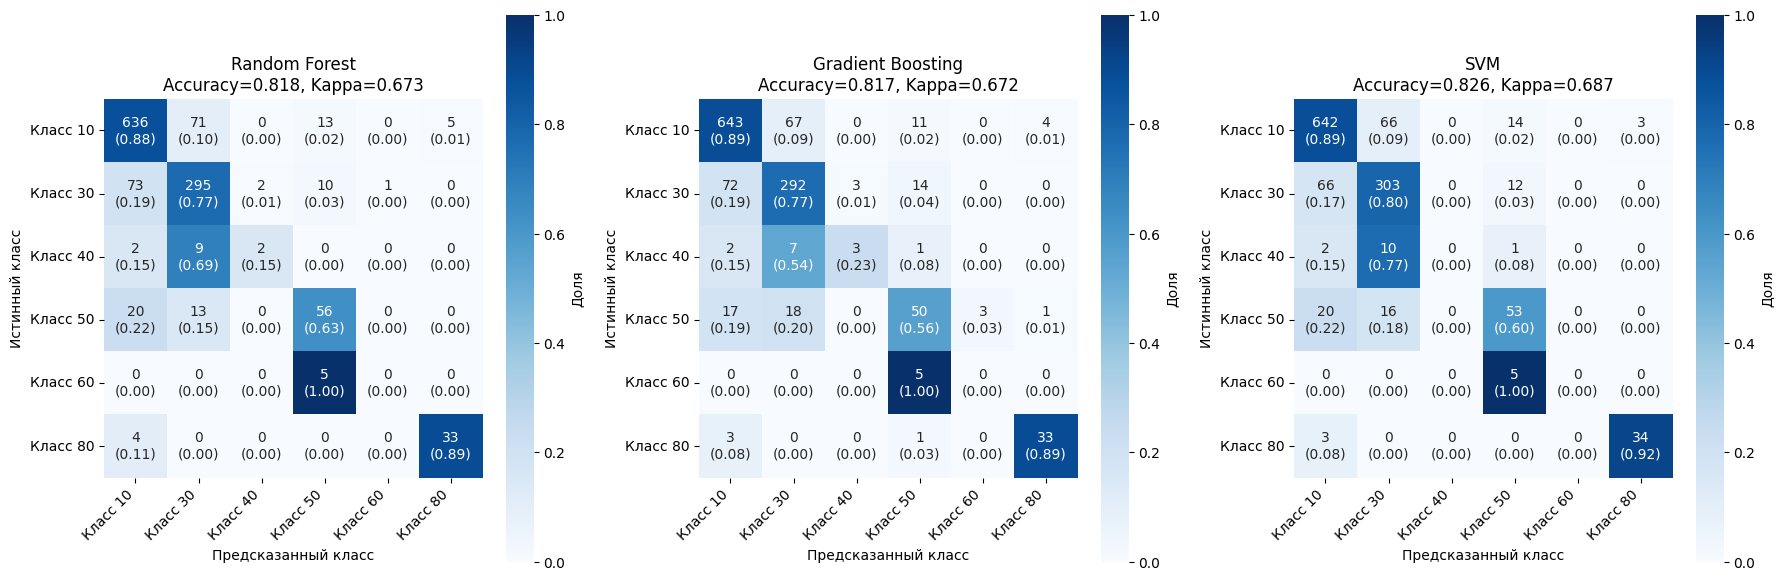

In [225]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, data) in zip(axes, results.items()):
    cm, indices = clean_confusion_matrix(data["matrix"])

    # Нормализация по строкам
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = np.nan_to_num(cm / cm.sum(axis=1, keepdims=True))

    # Аннотации: абсолютное значение + доля
    annot = [
        [f"{cm[i, j]}\n({cm_norm[i, j]:.2f})" for j in range(len(cm))]
        for i in range(len(cm))
    ]

    sns.heatmap(
        cm_norm,
        annot=annot,
        fmt="",
        cmap="Blues",
        square=True,
        vmin=0,
        vmax=1,
        ax=ax,
        cbar_kws={"label": "Доля"}
    )

    labels = [f"Класс {i}" for i in indices]
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels, rotation=0)
    ax.set_title(
        f"{name}\nAccuracy={data['accuracy']:.3f}, Kappa={data['kappa']:.3f}"
    )
    ax.set_xlabel("Предсказанный класс")
    ax.set_ylabel("Истинный класс")

plt.tight_layout()
plt.show()


In [226]:
metrics_df = pd.DataFrame({
    "Модель": ["Random Forest", "Gradient Boosting", "SVM"],
    "Overall Accuracy": [
        rf_confusion_matrix.accuracy().getInfo(),
        gb_confusion_matrix.accuracy().getInfo(),
        svm_confusion_matrix.accuracy().getInfo()
    ],
    "Kappa": [
        rf_confusion_matrix.kappa().getInfo(),
        gb_confusion_matrix.kappa().getInfo(),
        svm_confusion_matrix.kappa().getInfo()
    ]
})

metrics_df


,Модель,Overall Accuracy,Kappa
0,Random Forest,0.8176,0.673486
1,Gradient Boosting,0.8168,0.672135
2,SVM,0.8256,0.687373


7.13. Выберите лучшую модель по метрике Каппа и примените её для **классификации всей новой области интереса (выберите ее на карте, также, как делали это вначале)**. Отобразите результат на карте с легендой классов.

In [242]:
map_roi = geemap.Map(center=[35.95, -83.95], zoom=11)

map_roi.add_draw_control()

map_roi

Map(center=[35.95, -83.95], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [243]:
new_roi = map_roi.user_roi

In [244]:
year = 2023
start_date = f"{year}-03-01"
end_date = f"{year}-10-30"
max_cloud_pct = 25

s2_mosaic = s2_collection.median().clip(new_roi)

# NDVI
ndvi = s2_mosaic.normalizedDifference(["B8", "B4"]).rename("NDVI")

# NDWI
ndwi = s2_mosaic.normalizedDifference(["B3", "B8"]).rename("NDWI")

# NDBI
ndbi = s2_mosaic.normalizedDifference(["B11", "B8"]).rename("NDBI")

# EVI
evi = s2_mosaic.expression(
    "2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))",
    {
        "NIR": s2_mosaic.select("B8"),
        "RED": s2_mosaic.select("B4"),
        "BLUE": s2_mosaic.select("B2"),
    }
).rename("EVI")

composite_with_indices = (
    s2_mosaic
    .addBands([ndvi, ndwi, ndbi, evi])
)

print(composite_with_indices.bandNames().getInfo())

['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'NDVI', 'NDWI', 'NDBI', 'EVI']


In [256]:
final_features = ["B4", "B11", "NDVI", "NDWI", "NDBI", "EVI"]

classified_image = composite_with_indices.select(
    final_features
).classify(svm_classifier)


In [257]:
class_palette = [
    "#006400",  # лес — тёмно-зелёный
    "#7CFC00",  # растительность — салатовый
    "#FFD700",  # сельхоз — золотисто-жёлтый
    "#FF0000",  # застройка — красный
    "#0000FF",  # вода — синий
    "#808080",  # прочее — серый
]

map_result = geemap.Map()
map_result.centerObject(new_roi, 11)

map_result.addLayer(
    classified_image,
    {
        "min": 10,
        "max": 80,
        "palette": class_palette
    },
    "Классификация земного покрова (SVM)"
)

map_result.addLayer(
    new_roi,
    {"color": "black"},
    "Новая область интереса"
)

map_result

Map(center=[36.02336887132117, -83.9280535000001], controls=(WidgetControl(options=['position', 'transparent_b…

7.14. **Экспортируйте результат** классификации в формате GeoTIFF с сохранением геопривязки.

In [ ]:
geemap.download_ee_image(
    image=classified_image,
    filename="classification.tif",
    scale=10,
    region=new_roi,
    crs="EPSG:32637"
)

  0%|          |0/15050 tiles [00:00<?]